# Latihan Geospatial Data Science dengan Geopandas

## Persiapan Modul dan data

Sebelum melakukan pengolahan data dengan Geopandas. Perlu terlebih dahulu melakukan installasi pada environment yang dimiliki. Untuk melakukan installasi Geopandas gunakan conda :

`conda install geopandas`

In [43]:
import geopandas as gpd

In [44]:
gpd.__version__

'1.1.3'

Selanjutnya untuk latihan akan menggunakan set data Slemen:

In [45]:
import os

if not (os.path.isdir('sleman-dataset')):
    !git clone https://github.com/danylaksono/datasets.git
else:
    print('Folder sudah ada, tidak perlu download ulang!')

fatal: destination path 'datasets' already exists and is not an empty directory.


Perintah berikut memanggil data shapefile `Batas_Desa.shp` dan mengkorvesinya menjadi sebuah **GeoDataFrame**:

In [46]:
batas_desa_gdf = gpd.read_file('datasets/shapefiles/Batas_Desa.shp')

Kita dapat melihat beberapa keterangan dari data tersebut menggunakanperintah-perintah berikut:

In [47]:
batas_desa_gdf.head()

,STATUS_KOT,KODE_2008,DESA_2008,KEC_2008,KAB_2008,PROP_2008,geometry
0,DESA,-2147483648,HARGO BINANGUN,PAKEM,SLEMAN,DIY,"POLYGON ((435418.406 9163174, 435478.844 91631..."
1,DESA,-2147483648,GIRI KERTO,TURI,SLEMAN,DIY,"POLYGON ((435418.406 9163174, 435470.219 91629..."
2,DESA,-2147483648,GLAGAH HARJO,CANGKRINGAN,SLEMAN,DIY,"POLYGON ((439401.938 9162042, 439542.531 91619..."
3,DESA,-2147483648,KEPUH HARJO,CANGKRINGAN,SLEMAN,DIY,"POLYGON ((438780.562 9162126, 438850.562 91621..."
4,DESA,-2147483648,UMBUL HARJO,CANGKRINGAN,SLEMAN,DIY,"POLYGON ((438780.562 9162126, 438811.625 91619..."


In [48]:
batas_desa_gdf.shape

(86, 7)

Karena GeoDataFrame adalah data spasial, maka kita dapat melakukan plotting dan melihat sistem proyeksi dari data tersebut:

<Axes: >

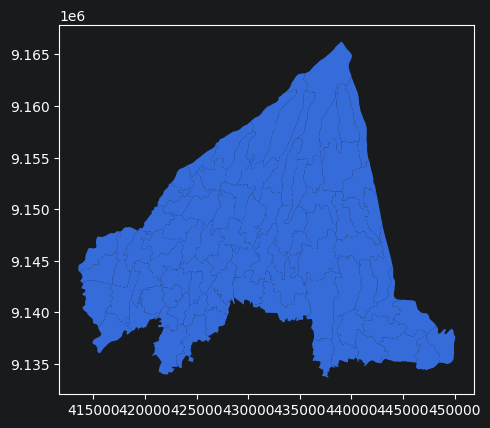

In [49]:
batas_desa_gdf.plot()

In [50]:
batas_desa_gdf.crs

<Projected CRS: EPSG:32749>
Name: WGS 84 / UTM zone 49S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 108°E and 114°E, southern hemisphere between 80°S and equator, onshore and offshore. Australia. Indonesia.
- bounds: (108.0, -80.0, 114.0, 0.0)
Coordinate Operation:
- name: UTM zone 49S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Pra-pengolahan data

Pada bagian ini kita akan mempersiapkan pengolahan data kecil-kecilan atau dalam kegiatan Data Science dikenal dengan istilah 'Data Wrangling' atau 'Data Cleaning'. Pertama kita lihat dulu kolom-kolom yang terdapat pada data kita:

### Pembersihan data

In [51]:
batas_desa_gdf.columns

Index(['STATUS_KOT', 'KODE_2008', 'DESA_2008', 'KEC_2008', 'KAB_2008',
       'PROP_2008', 'geometry'],
      dtype='str')

Kita tidak memerlukan kolom status, kode, kab dan prov (karena seluruh data jelas ada di sleman)

In [52]:
batas_desa_gdf = batas_desa_gdf[['DESA_2008', 'KEC_2008', 'geometry']]
batas_desa_gdf.head()

,DESA_2008,KEC_2008,geometry
0,HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631..."
1,GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629..."
2,GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619..."
3,KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621..."
4,UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619..."


Nama kolom tersebut cukup menggangu. Kita dapat merubah nama kolom dari sebuah DataFrame dengan mudah menggunakan perintah GeoPandas:

In [53]:
kolombaru = {'DESA_2008': 'desa', 'KEC_2008': 'kecamatan'}

In [54]:
batas_desa_gdf.rename(columns=kolombaru, inplace=True)
batas_desa_gdf.head()

,desa,kecamatan,geometry
0,HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631..."
1,GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629..."
2,GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619..."
3,KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621..."
4,UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619..."


Selanjutnya kita dapat mendefinisikan sebuah index. Sama seperti Pandas, index digunakan sebagai kunci unik yang mendefinisakan tiap baris pada sebuah Dataframe. Kita dapat melakukan slicing data dengan lebih mudah pada index yang kita ketahui namanya daripada kalau kita meggunakan sebuah urutan angka seperti diatas:

In [55]:
batas_desa_gdf = batas_desa_gdf.set_index("desa")
batas_desa_gdf.head()

,kecamatan,geometry
desa,,
HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631..."
GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629..."
GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619..."
KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621..."
UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619..."


Lalu, Kita ingin menambahkan kolom baru berupa luasan tiap desa:

In [56]:
batas_desa_gdf["area"] = batas_desa_gdf.area
batas_desa_gdf.head()

,kecamatan,geometry,area
desa,,,
HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631...",2.604238e+07
GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629...",1.369871e+07
GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619...",6.892411e+06
KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621...",7.910634e+06
UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619...",7.363010e+06


Karena luasan tersebut dalam format yang sulit dicerna kita dapat menambahkan kolom lain dengan satuan yang lebih mudah dipahami:

In [57]:
batas_desa_gdf["area_km"] = batas_desa_gdf["area"]/1000
batas_desa_gdf.head()

,kecamatan,geometry,area,area_km
desa,,,,
HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631...",2.604238e+07,26042.375453
GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629...",1.369871e+07,13698.712687
GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619...",6.892411e+06,6892.411266
KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621...",7.910634e+06,7910.633766
UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619...",7.363010e+06,7363.010297


## Pengecekan data sederhana

Selanjutnya kita dapat melakukan analisis atribut sederhana. Seperti yang kita lakukan dengan Pandas. kita juga dapat melaukan analisis atribut dengan GeoPandas seperti berikut:

In [58]:
batas_desa_gdf.groupby(['kecamatan']).agg(['count'])['geometry']

,count
kecamatan,
BERBAH,4
CANGKRINGAN,5
DEPOK,3
GAMPING,5
GODEAN,7
KALASAN,4
MINGGIR,5
MLATI,5
MOYUDAN,4


Perintah diatas menampilkan jumlah desa pada tiap kecamatan (lihat betapa sederhana perintah yang perlu kita buat untuk kebutuhan tersebut), Kita juga dapat membuat *slicing* sederhana untuk menampilkan desa denga luas lebih dari 10 ribu km persegi:

In [59]:
batas_desa_gdf[batas_desa_gdf['area_km'] > 10000]

,kecamatan,geometry,area,area_km
desa,,,,
HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631...",2.604238e+07,26042.375453
GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629...",1.369871e+07,13698.712687
WONO KERTO,TURI,"POLYGON ((430306.312 9158591, 430485.5 9158732...",1.229421e+07,12294.208391
WUKIR SARI,CANGKRINGAN,"POLYGON ((439011.562 9156581, 440003.625 91564...",1.349898e+07,13498.977594
WEDOMARTANI,NGEMPLAK,"POLYGON ((438481.938 9147414, 438512.344 91473...",1.262952e+07,12629.517484
PURWO MARTANI,KALASAN,"POLYGON ((438723.844 9144971, 438747.062 91449...",1.151312e+07,11513.123953
MAGUWOHARJO,DEPOK,"POLYGON ((438953.875 9143790, 438961.5 9143781...",1.531710e+07,15317.103500
CATUR TUNGGAL,DEPOK,"POLYGON ((430458.219 9140711, 430533.031 91407...",1.023722e+07,10237.222781


Juga, sama seperti Pandas kota dapat menggunakan fungsi `loc` untuk mencari ('locate') data dengan kriteria tertentu:

In [60]:
data_pakem = batas_desa_gdf.loc[batas_desa_gdf['kecamatan'] == 'PAKEM']
data_pakem.head()

,kecamatan,geometry,area,area_km
desa,,,,
HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631...",2.604238e+07,26042.375453
PURWO BINANGUN,PAKEM,"POLYGON ((435610.906 9161561, 435802.281 91614...",8.760292e+06,8760.291859
CANDI BINANGUN,PAKEM,"POLYGON ((434692.875 9156884, 434964.906 91568...",6.554894e+06,6554.894500
PAKEM BINANGUN,PAKEM,"POLYGON ((437040.125 9155093, 437061.75 915487...",4.724604e+06,4724.604047
HARJO BINANGUN,PAKEM,"POLYGON ((434719.375 9154814, 434869.406 91548...",5.303425e+06,5303.425312


<Axes: >

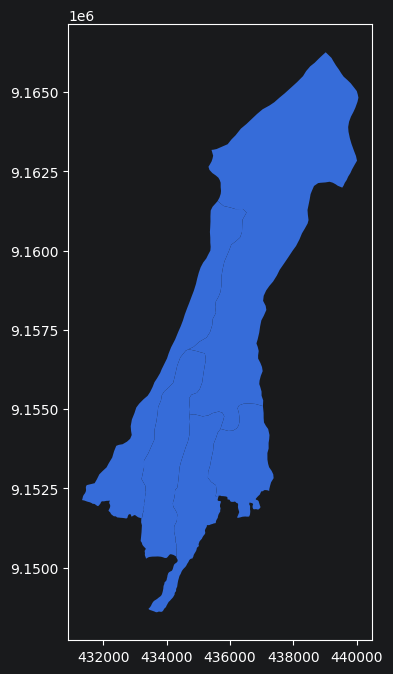

In [61]:
data_pakem.plot(figsize=(4,8))

Jika kita gabungkan kedua jenis query tersebut, kita dapat melakukan seperti ini:

In [62]:
batas_desa_gdf.loc[batas_desa_gdf['area'].idxmax()]

kecamatan                                                PAKEM
geometry     POLYGON ((435418.40625 9163174, 435478.84375 9...
area                                           26042375.453125
area_km                                           26042.375453
Name: HARGO BINANGUN, dtype: object

Perintah `idxmax` diatas digunakan untuk mencari Index (yang sebelumnya kita tentukan adalah nama desa) yang memiliki nilai maksimal untuk kolom yang dicari. Jika kita gunakan perintah `at()`, maka kita dapat memperoleh desa yang kita cari:

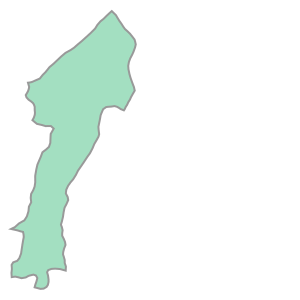

In [63]:
batas_desa_gdf.at['HARGO BINANGUN', 'geometry']

## Analisis Spasial Sederhana

Geopandas memiliki berbagai fungsi analisis spasial, meskipun dalam prakteknya seringkali akan kita gabungkan dengan library lain. Pada begian ini kita akan bahas sekilas mengenai bebrapa fungsi tersebut

## Persiapan dan Plotting Data

untuk contoh, kita dapat memanggil data lain dari dataset:

In [64]:
fasum_gdf = gpd.read_file('datasets/shapefiles/Fasilitas_Umum.shp')
fasum_gdf.head(10)

,ID,NAMA,Fungsi,geometry
0,11.0,GBI Sleman,Tempat Ibadah,POINT (428764.566 9147878.482)
1,11.0,Gereja Kerasulan baru,Tempat Ibadah,POINT (428621.916 9146721.884)
2,4.0,Kantor Polisi Resort Sleman,Kantor Pemerintahan,POINT (428812.287 9146744.065)
3,4.0,Kejaksaan,Kantor Pemerintahan,POINT (428972.342 9147099.066)
4,4.0,PLN,Kantor Pemerintahan,POINT (428951.9 9147062.583)
5,4.0,Balai Besar Latihan Ketransmig,Kantor Pemerintahan,POINT (428824.595 9147187.177)
6,7.0,TK Pertiwi I Beran,Pendidikan,POINT (428989.549 9147380.063)
7,4.0,BPD,Kantor Pemerintahan,POINT (429029.995 9147415.532)
8,8.0,Pustu Pandowoharjo,Kesehatan,POINT (430512.689 9147127.025)
9,7.0,TK Al-Hikmah,Pendidikan,POINT (430517.419 9146974.899)


Geopandas telah terintegrasi dan Matplotlib untuk menampilkan plotting dari Geodataframe yang sudah kita lihat sebelumnya. Dengan mengatur sedikit parameter Matplotlib, kita juga dapat menampilkna beberapa layer sekaligus:

<Axes: >

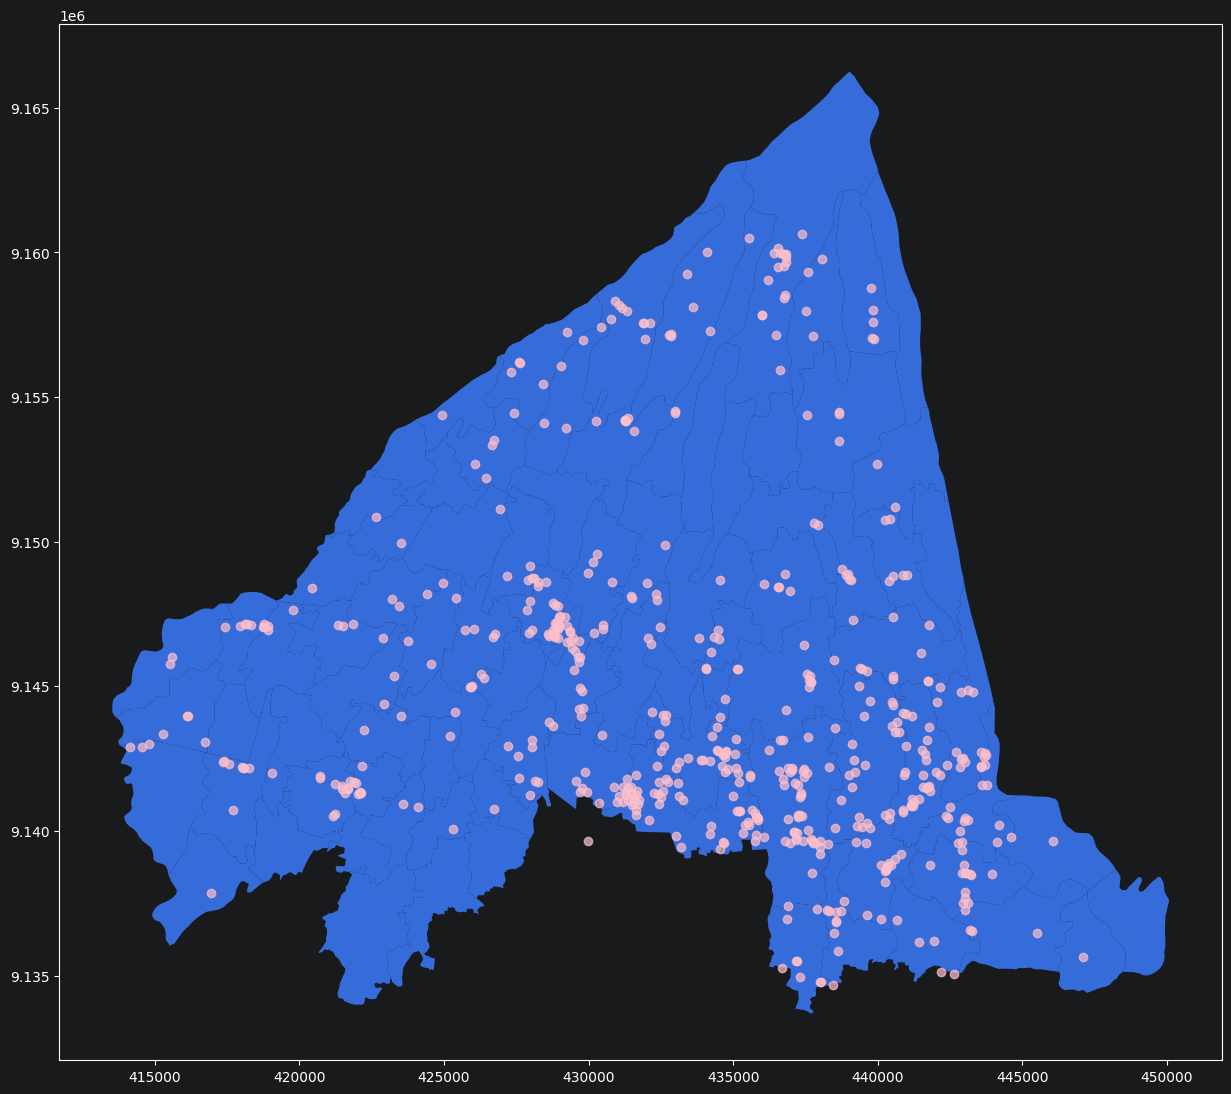

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,15))
batas_desa_gdf.plot(ax=ax)
fasum_gdf.plot(ax=ax, alpha=0.7, color='pink')

## Spatial Join

Sekarang kita akan menggabungkan data `batas_desa_gdf` dengan data `fasum_gdf`. Analisis ini disebut dengan `Spatial Join`, yaitu kita menggabungkan data berdasarkan lokasinya, Idenya adalah **Kita inin mengetahui tiap titik fasum ini terletak pada desa mana di Sleman?**

Sebelum melakukan pengabungan kita akan menghilangkan index yang kita buat di awal tadi:

In [66]:
batas_desa_gdf = batas_desa_gdf.reset_index()

In [67]:
batas_desa_gdf.head()

,desa,kecamatan,geometry,area,area_km
0,HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631...",2.604238e+07,26042.375453
1,GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629...",1.369871e+07,13698.712687
2,GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619...",6.892411e+06,6892.411266
3,KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621...",7.910634e+06,7910.633766
4,UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619...",7.363010e+06,7363.010297


ini kita lakukan sebagai langkah opsional nantinya kita akan menggabungkan deat tersebut dengan data fasum menggunakan perintah `sjoin`:

In [68]:
fasum_desa = gpd.sjoin(fasum_gdf, batas_desa_gdf, how='inner', predicate='intersects')
fasum_desa.head()

,ID,NAMA,Fungsi,geometry,index_right,desa,kecamatan,area,area_km
0,11.0,GBI Sleman,Tempat Ibadah,POINT (428764.566 9147878.482),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922
1,11.0,Gereja Kerasulan baru,Tempat Ibadah,POINT (428621.916 9146721.884),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922
2,4.0,Kantor Polisi Resort Sleman,Kantor Pemerintahan,POINT (428812.287 9146744.065),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922
3,4.0,Kejaksaan,Kantor Pemerintahan,POINT (428972.342 9147099.066),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922
4,4.0,PLN,Kantor Pemerintahan,POINT (428951.9 9147062.583),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922


Dengan fungsi `groupby()`, kita dapat melaukan analisis lebih lanjut:

In [69]:
fasum_desa.groupby(['Fungsi', 'desa'])["ID"].count()

Fungsi         desa          
Industri       BOKO HARJO         4
               DONOHARJO          1
               GIRI KERTO         1
               KALI TIRTO         2
               MAGUWOHARJO       13
                                 ..
Tempat Ibadah  WEDOMARTANI        2
               WONO KERTO         2
Terminal       HARGO BINANGUN     1
               TAMAN MARTANI      1
               WONO KERTO         1
Name: ID, Length: 214, dtype: int64

Hasilnya dapat kita simpan sebagai sebuah file baru:

In [70]:
fungsi_per_desa = fasum_desa.groupby(['Fungsi', 'desa'], as_index=False)["ID"].count()
fungsi_per_desa.to_csv('fungsi_fasum_tiap_desa.csv', index=False)

Kita juga dapat mnampilkan hasilnya dalam bentuk histogram untuk memperjelas:

<Axes: >

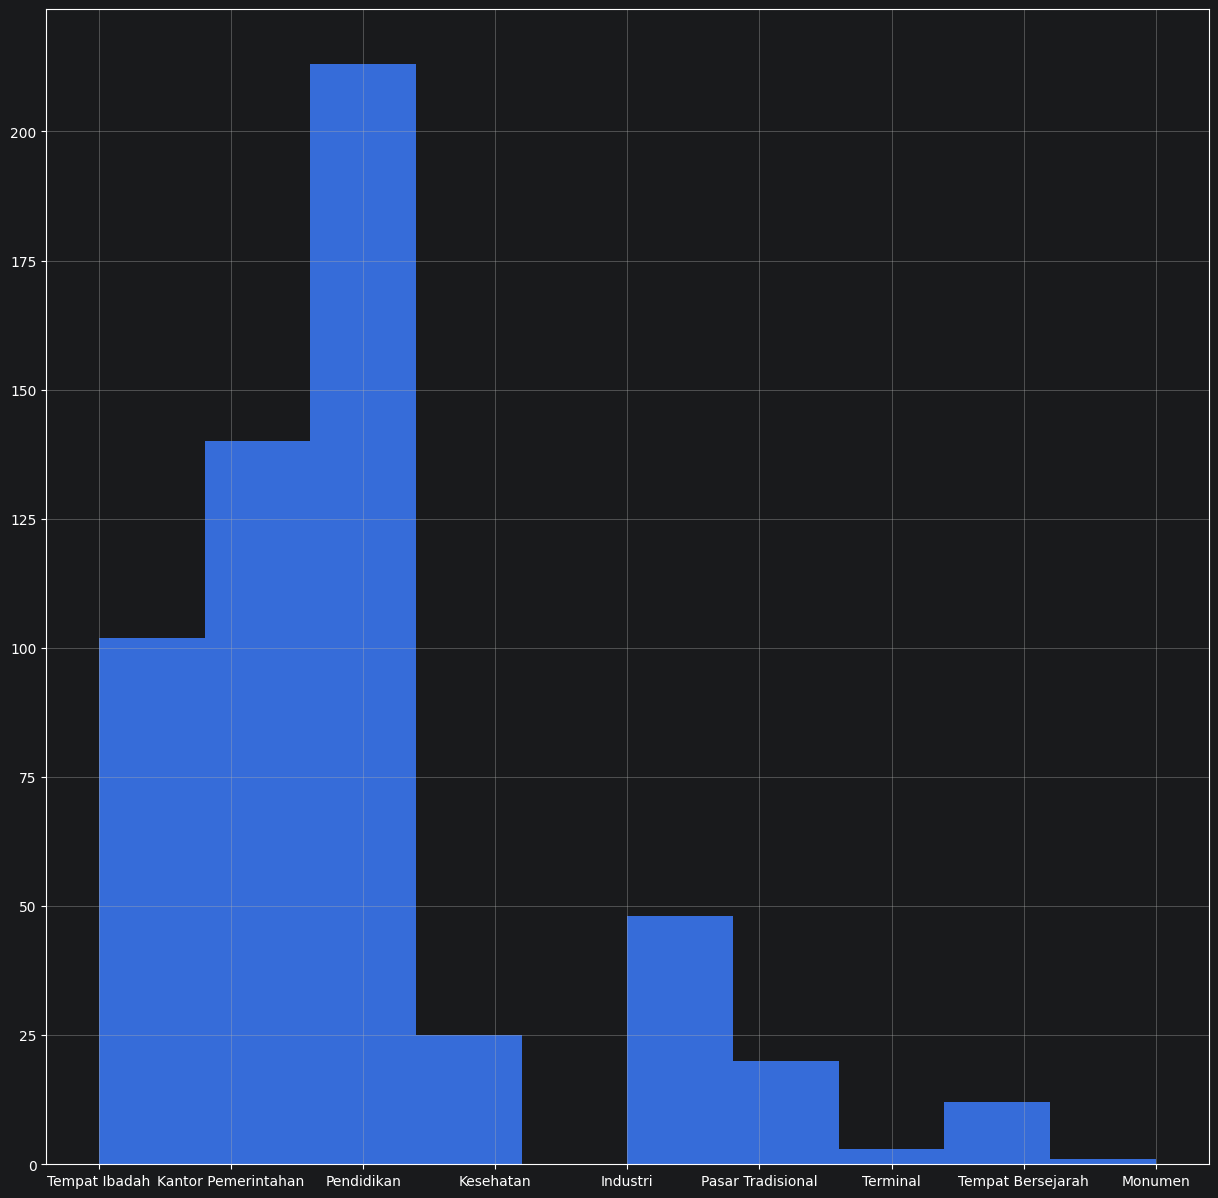

In [71]:
fasum_desa['Fungsi'].hist(figsize=(15,15))

Histogram juga dapat kita tampilkan berdasarkan kelompoknya:

array([[<Axes: title={'center': 'Industri'}>,
        <Axes: title={'center': 'Kantor Pemerintahan'}>,
        <Axes: title={'center': 'Kesehatan'}>],
       [<Axes: title={'center': 'Monumen'}>,
        <Axes: title={'center': 'Pasar Tradisional'}>,
        <Axes: title={'center': 'Pendidikan'}>],
       [<Axes: title={'center': 'Tempat Bersejarah'}>,
        <Axes: title={'center': 'Tempat Ibadah'}>,
        <Axes: title={'center': 'Terminal'}>]], dtype=object)

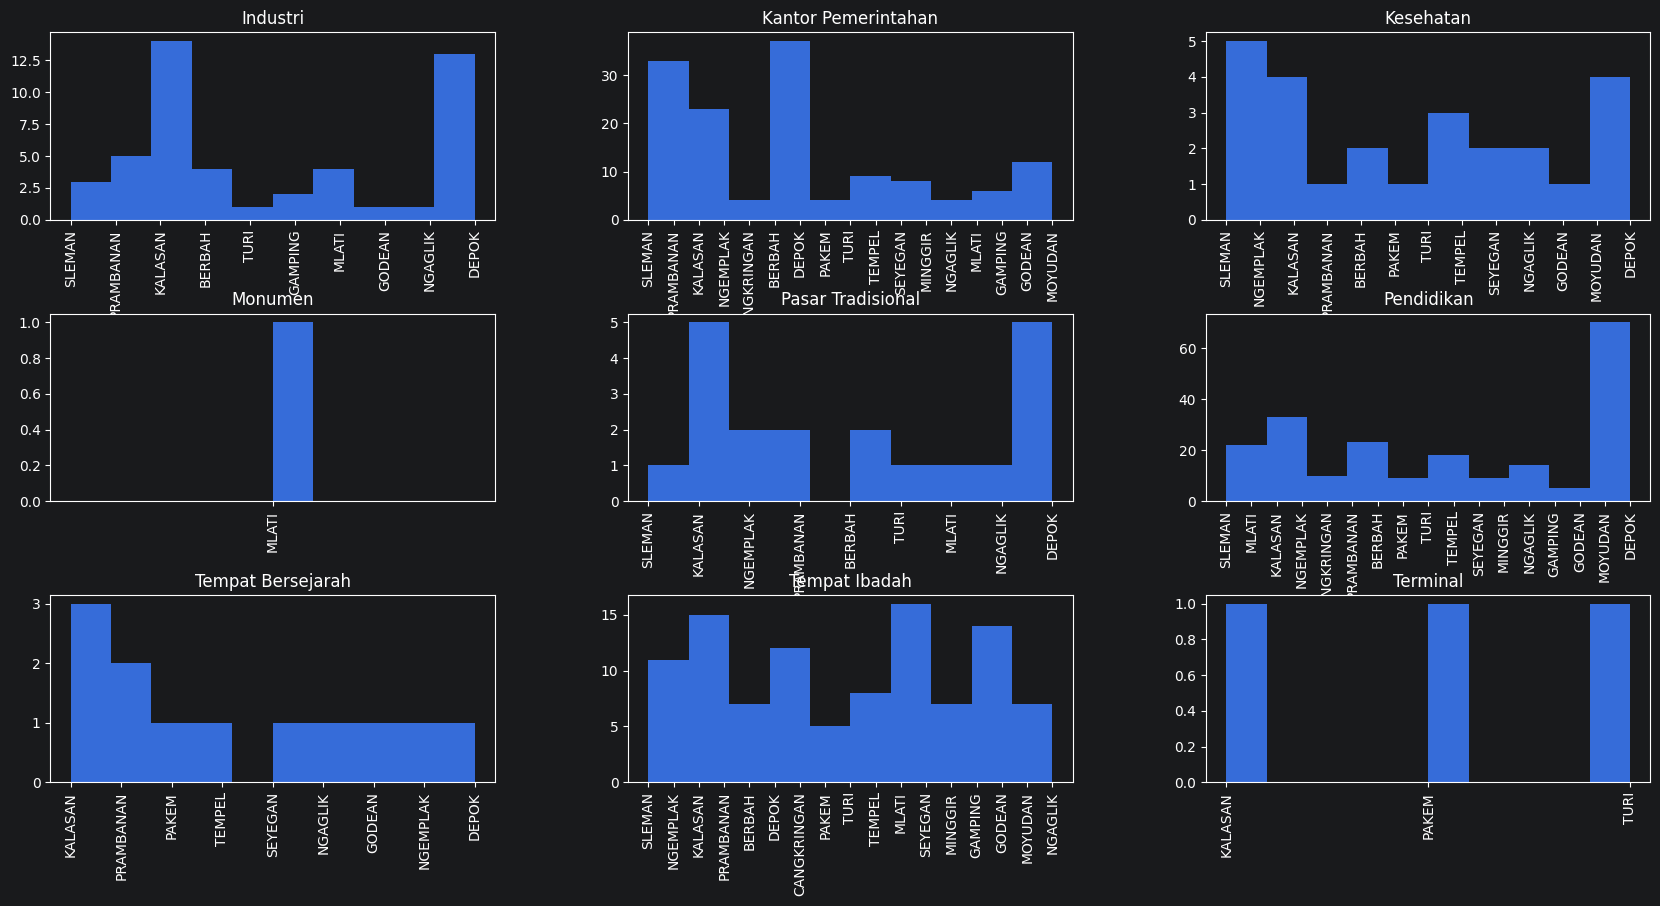

In [72]:
fasum_desa['kecamatan'].hist(figsize=(20,10), by=fasum_desa['Fungsi'])

`value_counts()` menghitung jumlah unik dari sebuah kolom pada pandas:

In [82]:
fasum_desa['desa'].value_counts()

desa
CATUR TUNGGAL    50
MAGUWOHARJO      47
TRIDADI          36
CONDONG CATUR    32
TIRTO MARTANI    30
                 ..
NOGOTIRTO         1
SIDOMOYO          1
SIDOARUM          1
SIDOREJO          1
SUMBERRAHAYU      1
Name: count, Length: 71, dtype: int64

Dengan demikian kita dapat menampilkan **lima besar desa dengan jumlah fasum terbanyak**

In [74]:
fasum_desa['desa'].value_counts().head(5)

desa
CATUR TUNGGAL    50
MAGUWOHARJO      47
TRIDADI          36
CONDONG CATUR    32
TIRTO MARTANI    30
Name: count, dtype: int64

Bagaimana kalau kita ingin menampilkan **desa yang memiliki jumlah sekolah terbanyak**

Kita dapat memisahkan terlebih dahulu data fasum pendidikan melelui proses slicing:

In [75]:
fasum_pendidikan = fasum_desa.loc[fasum_desa['Fungsi'] == 'Pendidikan']
fasum_pendidikan.head()

,ID,NAMA,Fungsi,geometry,index_right,desa,kecamatan,area,area_km
6,7.0,TK Pertiwi I Beran,Pendidikan,POINT (428989.549 9147380.063),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922
9,7.0,TK Al-Hikmah,Pendidikan,POINT (430517.419 9146974.899),28,PANDOWO HARJO,SLEMAN,7.278740e+06,7278.740281
11,7.0,SDN Dukuh I,Pendidikan,POINT (428850.934 9147794.075),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922
13,7.0,SMKN Sleman,Pendidikan,POINT (429177.526 9147390.769),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922
29,0.0,SMPN Tridadi,Pendidikan,POINT (429256.275 9147093.427),34,TRIDADI,SLEMAN,5.077171e+06,5077.170922


Selanjutnya hitung fasum tiap desa:

In [76]:
jumlah_fasum_pendidikan = fasum_pendidikan['desa'].value_counts()
jumlah_fasum_pendidikan

desa
CATUR TUNGGAL     39
MAGUWOHARJO       16
CONDONG CATUR     12
TRIDADI            9
SINDUADI           8
HARGO BINANGUN     7
TAMAN MARTANI      6
TIRTO MARTANI      6
PURWO MARTANI      6
WEDOMARTANI        6
KALI TIRTO         5
GIRI KERTO         5
SENDANGSARI        5
SINDUHARJO         5
SELO MARTANI       4
BOKO HARJO         4
MADU REJO          4
TEGAL TIRTO        4
KEPUH HARJO        4
MERDIKO REJO       4
WUKIR SARI         3
UMBUL HARJO        3
BIMO MARTANI       3
SUMBER HARJO       3
WONO KERTO         3
SARI HARJO         3
PANDOWO HARJO      2
PURWO BINANGUN     2
DONOKERTO          2
DONOHARJO          2
TRIHANGGO          2
SIDOLUHUR          2
SUMBER AGUNG       2
SARDONOHARJO       2
SENDANGADI         1
WIDODO MARTANI     1
UMBULMARTANI       1
SAMBI REJO         1
JOGO TIRTO         1
SENDANG TIRTO      1
BANGUN KERTO       1
MARGO REJO         1
LUMBUNG REJO       1
TRIHARJO           1
SUMBERADI          1
MARGOAGUNG         1
MARGOKATON         1
BANYU RE

In [77]:
fasum_pendidikan.loc[fasum_desa['desa']=='CATUR TUNGGAL'].head(10)

,ID,NAMA,Fungsi,geometry,index_right,desa,kecamatan,area,area_km
430,0.0,Fak. Ekonomi D3,Pendidikan,POINT (431651.889 9140549.528),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
431,0.0,LPPT UGM,Pendidikan,POINT (432252.765 9141317.587),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
432,0.0,Fak. Kedokteran Hewan,Pendidikan,POINT (432404.94 9141284.41),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
433,0.0,Fak. Peternakan,Pendidikan,POINT (432521.058 9141165.648),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
434,0.0,Kampus UNY,Pendidikan,POINT (432425 9140926),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
435,0.0,Kampus UNY,Pendidikan,POINT (432075.156 9140367.979),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
490,5.0,Universitas Proklamasi '45,Pendidikan,POINT (435760 9140603),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
491,6.0,Universitas Atmajaya,Pendidikan,POINT (435350.052 9139937.229),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
494,10.0,STT Nas,Pendidikan,POINT (435655 9140719),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781
495,11.0,STIEPARI API,Pendidikan,POINT (435804 9140443),64,CATUR TUNGGAL,DEPOK,1.023722e+07,10237.222781


In [78]:
batas_desa_gdf.head()

,desa,kecamatan,geometry,area,area_km
0,HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631...",2.604238e+07,26042.375453
1,GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629...",1.369871e+07,13698.712687
2,GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619...",6.892411e+06,6892.411266
3,KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621...",7.910634e+06,7910.633766
4,UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619...",7.363010e+06,7363.010297


In [79]:
batas_desa_gdf['jumlah_sekolah'] = batas_desa_gdf.desa.map(jumlah_fasum_pendidikan)
batas_desa_gdf.head(10)

,desa,kecamatan,geometry,area,area_km,jumlah_sekolah
0,HARGO BINANGUN,PAKEM,"POLYGON ((435418.406 9163174, 435478.844 91631...",2.604238e+07,26042.375453,7.0
1,GIRI KERTO,TURI,"POLYGON ((435418.406 9163174, 435470.219 91629...",1.369871e+07,13698.712687,5.0
2,GLAGAH HARJO,CANGKRINGAN,"POLYGON ((439401.938 9162042, 439542.531 91619...",6.892411e+06,6892.411266,NaN
3,KEPUH HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438850.562 91621...",7.910634e+06,7910.633766,4.0
4,UMBUL HARJO,CANGKRINGAN,"POLYGON ((438780.562 9162126, 438811.625 91619...",7.363010e+06,7363.010297,3.0
5,WONO KERTO,TURI,"POLYGON ((430306.312 9158591, 430485.5 9158732...",1.229421e+07,12294.208391,3.0
6,PURWO BINANGUN,PAKEM,"POLYGON ((435610.906 9161561, 435802.281 91614...",8.760292e+06,8760.291859,2.0
7,MERDIKO REJO,TEMPEL,"POLYGON ((430306.312 9158591, 430317.875 91583...",7.085883e+06,7085.883094,4.0
8,BANGUN KERTO,TURI,"POLYGON ((430403.812 9157588, 430484.188 91575...",6.207181e+06,6207.181344,1.0
9,WUKIR SARI,CANGKRINGAN,"POLYGON ((439011.562 9156581, 440003.625 91564...",1.349898e+07,13498.977594,3.0


In [80]:
batas_desa_gdf['jumlah_sekolah'] = batas_desa_gdf['jumlah_sekolah'].fillna(0)

<Axes: >

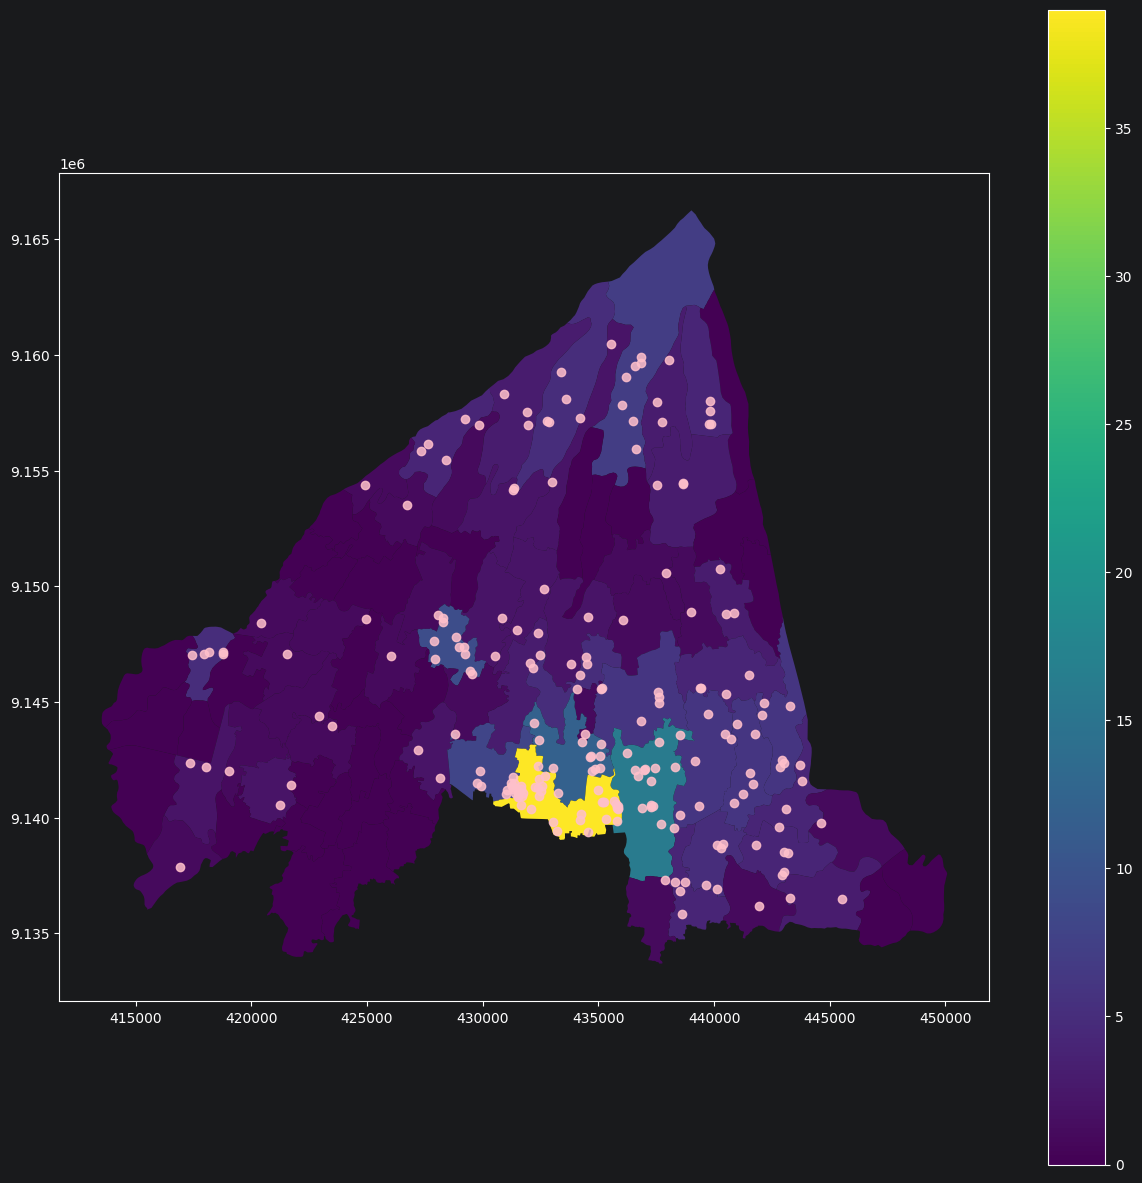

In [81]:
fig, ax = plt.subplots(figsize=(15,15))
batas_desa_gdf.plot(ax=ax, column='jumlah_sekolah', legend=True)
fasum_pendidikan.plot(ax=ax, alpha=0.85, color='pink')